In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import storage
import io
import joblib

In [2]:
df = pd.read_csv('../processed.csv')
print(df.columns)
df.head()

Index(['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0',
       'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views',
       'hours', 'engagement', 'description_json', 'duration_seconds'],
      dtype='object')


,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,cost_nzd,views,hours,engagement,description_json,duration_seconds
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,NaN,38409.0,64.3328,682.0,"{""play_by_play"": ""A male rugby player in a bla...",12.839229
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,NaN,235384.0,544.8062,3800.0,"{""play_by_play"": ""A male rugby player wearing ...",14.279229
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,NaN,274028.0,712.1043,3261.0,"{""play_by_play"": ""A group of male rugby player...",19.644082
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",NaN,281319.0,623.9321,4929.0,"{""play_by_play"": ""A male rugby player runs up ...",15.625215
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,NaN,438181.0,894.3045,9850.0,"{""play_by_play"": ""A male All Black player trac...",13.605215


### extract json

In [3]:
# json schema
# {
# "play_by_play": "",
# "content_theme": [""],
# "format_access": [""],
# "people": [""],
# "brands": [""],
# "event": [""],
# "tone": [""],
# "context": [""],
# "overall_team": [""],
# "audio_format": [""]
# }

In [4]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]


def _parse_json(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None
    try:
        return json.loads(text)
    except Exception:
        return None


json_dicts = df["description_json"].map(_parse_json)
df["description"] = json_dicts.map(
    lambda d: ((d or {}).get("play_by_play") or "").strip() or pd.NA
).astype("string")

# keep parsed dicts in scope for the encoding cell
json_by_idx = {idx: d for idx, d in zip(df.index, json_dicts) if d is not None}
print(f"parsed: {len(json_by_idx)} / {len(df)}")


parsed: 12105 / 12105


In [5]:
df = df[df['description'].notna()]

In [6]:
df

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,cost_nzd,views,hours,engagement,description_json,duration_seconds,description
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,NaN,38409.0,64.3328,682.0,"{""play_by_play"": ""A male rugby player in a bla...",12.839229,A male rugby player in a black jersey sprints ...
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,NaN,235384.0,544.8062,3800.0,"{""play_by_play"": ""A male rugby player wearing ...",14.279229,A male rugby player wearing a black jersey bre...
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,NaN,274028.0,712.1043,3261.0,"{""play_by_play"": ""A group of male rugby player...",19.644082,A group of male rugby players in pink training...
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",NaN,281319.0,623.9321,4929.0,"{""play_by_play"": ""A male rugby player runs up ...",15.625215,A male rugby player runs up and kicks a rugby ...
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,NaN,438181.0,894.3045,9850.0,"{""play_by_play"": ""A male All Black player trac...",13.605215,A male All Black player tracks a high kick com...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12100,Organic | Website,2024,All Blacks,YT,Short Video,Social,Ticketing,All,https://www.youtube.com/watch?v=Z_KNhpwG7FU,join the all blacks as they face world-class o...,NaN,1753.0,7.2166,7.0,"{""play_by_play"": ""A fast-paced, black-and-whit...",15.055333,"A fast-paced, black-and-white promotional vide..."
12101,Organic | Website,2024,All Blacks,YT,Short Video,Social,WIP,WIP,https://www.youtube.com/watch?v=iujkO1ENd6E,kia ora team 🏉. your champion black ferns retu...,NaN,53011.0,225.6834,49.0,"{""play_by_play"": ""A promotional video displayi...",15.055333,A promotional video displaying highlights of B...
12102,Organic | Website,2024,All Blacks,YT,Short Video,Social,WIP,WIP,https://www.youtube.com/watch?v=-1S0K6gmZ4s,this is the moment you've been waiting for. tu...,NaN,4.0,0.0000,0.0,"{""play_by_play"": ""Dude Perfect and All Blacks ...",15.055333,Dude Perfect and All Blacks representatives in...
12103,Organic | Website,2024,All Blacks,YT,Short Video,Social,WIP,WIP,https://www.youtube.com/watch?v=DI2db1yQoRc,witness an exclusive adventure as the legendar...,NaN,0.0,0.0000,0.0,"{""play_by_play"": "" Dude Perfect and New Zealan...",15.055333,Dude Perfect and New Zealand rugby players pre...


### encoding 

In [7]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]

# build per-field token-sets per row index for O(1) lookups
field_to_sets = {
    field: {idx: set(d.get(field, []) or []) for idx, d in json_by_idx.items()}
    for field in JSON_LIST_FIELDS
}

vocabulary = {
    field: {
        value
        for d in json_by_idx.values()
        for value in (d.get(field, []) or [])
    }
    for field in JSON_LIST_FIELDS
}

oh_columns = {
    f"json_{field}_{value}": pd.Series(
        [
            int(
                field_to_sets[field].get(idx) is not None
                and value in field_to_sets[field][idx]
            )
            for idx in df.index
        ],
        index=df.index,
        dtype="int8",
    )
    for field in JSON_LIST_FIELDS
    for value in sorted(vocabulary[field])
}

df = pd.concat([df, pd.DataFrame(oh_columns)], axis=1)

# raw JSON column no longer needed
df = df.drop(columns=["description_json"])


from collections import Counter

import regex

POST_TITLE_COLUMN = "content"
HASHTAG_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_])#([\p{L}\p{N}_]+)")
MENTION_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_@])@([\p{L}\p{N}_][\p{L}\p{N}_.]*)")
EMOJI_PATTERN = regex.compile(
    r"(?:\p{Regional_Indicator}{2}|[#*0-9]\uFE0F?\u20E3|"
    r"\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?"
    r"(?:\u200D\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?)*)"
)


def _multi_hot_encode(frame, token_lists, prefix, column_name, min_frequency):
    if min_frequency < 1:
        raise ValueError("min_frequency must be at least 1")

    old_columns = [column for column in frame.columns if column.startswith(f"{prefix}_")]
    if old_columns:
        frame.drop(columns=old_columns, inplace=True)

    unique_tokens = token_lists.map(lambda tokens: list(dict.fromkeys(tokens)))
    frequencies = Counter(token for tokens in unique_tokens for token in tokens)
    vocabulary = sorted(token for token, count in frequencies.items() if count >= min_frequency)

    new_columns = {
        f"{prefix}_count": token_lists.map(len).astype("int16"),
        **{
            column_name(token): unique_tokens.map(
                lambda tokens, value=token: int(value in tokens)
            ).astype("int8")
            for token in vocabulary
        },
    }
    frame = pd.concat([frame, pd.DataFrame(new_columns, index=frame.index)], axis=1)
    return frame


def hashtag_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [tag.casefold() for tag in HASHTAG_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "hashtag", lambda tag: f"hashtag_{tag}", min_frequency
    )


def mention_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [mention.rstrip(".").casefold() for mention in MENTION_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "mention", lambda mention: f"mention_{mention}", min_frequency
    )


def emoji_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(EMOJI_PATTERN.findall)

    def emoji_column(value):
        codepoints = "_".join(f"{ord(char):x}" for char in value)
        return f"emoji_u{codepoints}"

    return _multi_hot_encode(frame, tokens, "emoji", emoji_column, min_frequency)


df = hashtag_encode(df)
df = mention_encode(df)
df = emoji_encode(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,emoji_u1faf3_1f3fd,emoji_u1faf4_1f3fd,emoji_u1faf5,emoji_u1faf5_1f3fc,emoji_u1faf5_1f3fd,emoji_u1faf6,emoji_u1faf6_1f3fc,emoji_u1faf6_1f3fd,emoji_u1faf6_1f3fe,emoji_u1faf8
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,...,0,0,0,0,0,0,0,0,0,0
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,...,0,0,0,0,0,0,0,0,0,0
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,...,0,0,0,0,0,0,0,0,0,0
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",...,0,0,0,0,0,0,0,0,0,0
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,...,0,0,0,0,0,0,0,0,0,0


# NLP

### clustering descriptions

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['description'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/379 [00:00<?, ?it/s]

Best k: 3
Best silhouette score: 0.06132595


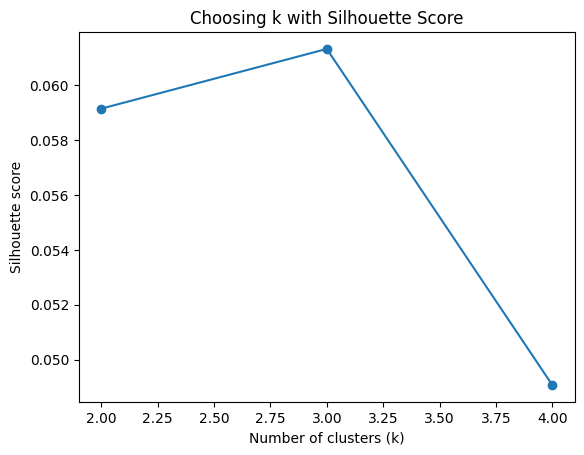

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 5)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[1 2 1 ... 1 1 1]


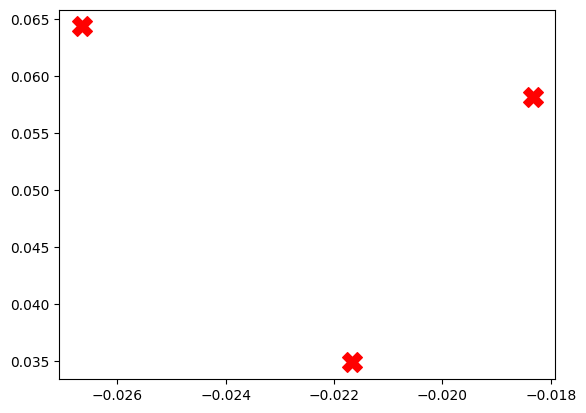

In [10]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['description_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### clustering title

In [11]:
# from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['content'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/379 [00:00<?, ?it/s]

Best k: 12
Best silhouette score: 0.06871473


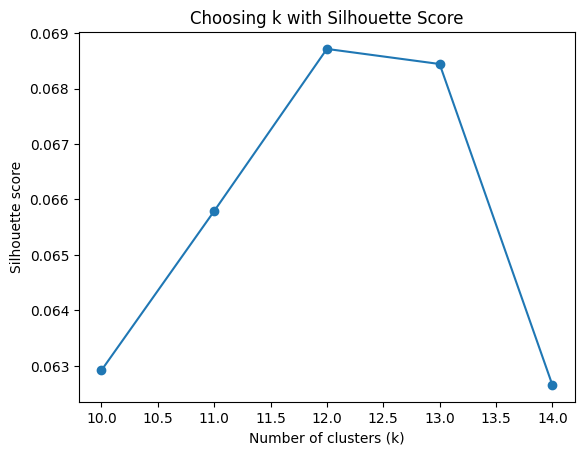

In [12]:

k_range = range(10, 15)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[0 8 5 ... 3 3 3]


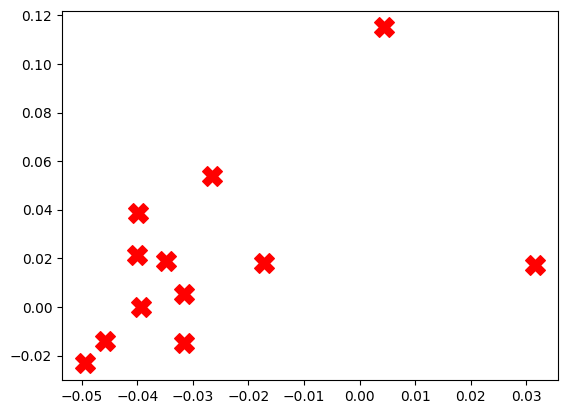

In [13]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=12,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['title_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### drop stuff

In [14]:
# ----- ONE-HOT categorical (was `oh-cat-and-counts`) -----
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_TO_OH = [
    "platform", "page",
]

for col in CATEGORICAL_TO_OH:
    n = df[col].nunique(dropna=True)
    flag = " (constant; skipped)" if n <= 1 else ""
    print(f"  {col}: nunique={n}{flag}")

oh_cols = [c for c in CATEGORICAL_TO_OH if df[c].nunique(dropna=True) > 0]
if oh_cols:
    oh = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = pd.DataFrame(
        oh.fit_transform(df[oh_cols].astype(str)),
        columns=oh.get_feature_names_out(oh_cols),
        index=df.index,
    ).astype("int8")
    df = pd.concat([df, encoded], axis=1)
    print(f"added {encoded.shape[1]} one-hot columns from {oh_cols}")
else:
    print("no varying categorical columns to one-hot")

# Aliases for readable count features.
for src, dst in [("mention_count", "n_mentions"),
                  ("hashtag_count", "n_hashtags"),
                  ("emoji_count",   "n_emojis")]:
    if src in df.columns and dst not in df.columns:
        df[dst] = df[src]

print("alias counts -> n_mentions / n_hashtags / n_emojis:")
for dst in ("n_mentions", "n_hashtags", "n_emojis"):
    if dst in df.columns:
        print(f"  {dst}: total={df[dst].sum():,}  mean={df[dst].mean():.2f}  max={df[dst].max()}")

# ----- DROP / round / finalize (was af73cb2e + df534eab) -----
DROP = [
    'campaign',
    'platform',
    'media_type',
    "category_l0",
    "category_l1",
    "category_l2",
    "page",
    "platform",
    'url',
    'content',
    'hours',
    'description',
    'cost_nzd',
    'year'
]

df = df.drop(columns=DROP)

df['duration_seconds'] = df['duration_seconds'].round().astype(int)
df = df.drop(columns=['n_hashtags', 'n_emojis', 'n_mentions'])

# ----- Validity mask (was 36eeeb60 + 05abae6f) -----
mask = (df['views'] > 0) & (df['engagement'] > 0)
print(f"drop {(~mask).sum()} rows; remaining: {mask.sum()}")
df = df[mask]

# ----- IQR outlier slicing (was e2e51437 + 088d26b4) -----
print(f"IQR pre-slice: {len(df)} rows")
for col in ['views', 'engagement']:
    Q1 = df[col].quantile(0.1)
    Q3 = df[col].quantile(0.9)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f"  {col}: drop {before - len(df)} rows -> {len(df)} remaining")

# ----- Deterministic train / val(inner) / test split (single source of truth) -----
from sklearn.model_selection import train_test_split

idx_tr_full, idx_te = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42
)
idx_tr, idx_vl_inner = train_test_split(
    idx_tr_full, test_size=0.2, random_state=42
)
print(f"train: {len(idx_tr)}  val(inner): {len(idx_vl_inner)}  test: {len(idx_te)}")
print(f"total : {len(idx_tr) + len(idx_vl_inner) + len(idx_te)} (=={len(df)})")


  platform: nunique=4
  page: nunique=7
added 11 one-hot columns from ['platform', 'page']
alias counts -> n_mentions / n_hashtags / n_emojis:
  n_mentions: total=4,492  mean=0.37  max=7
  n_hashtags: total=19,314  mean=1.60  max=18
  n_emojis: total=15,129  mean=1.25  max=16
drop 823 rows; remaining: 11279
IQR pre-slice: 11279 rows
  views: drop 297 rows -> 10982 remaining
  engagement: drop 222 rows -> 10760 remaining
train: 6886  val(inner): 1722  test: 2152
total : 10760 (==10760)


### LINREG NN

In [15]:
# # X / y setup using shared split from Data prep above
# from sklearn.preprocessing import StandardScaler, RobustScaler

# DROP_COLS = ['views', 'engagement']

# X_all = df.drop(columns=DROP_COLS)
# y_all = df[['engagement', 'views']]

# NUMERIC_COLS = [c for c in [
#     'duration_seconds', 'description_cluster', 'title_cluster',
#     'n_mentions', 'n_hashtags', 'n_emojis',
#     'hashtag_count', 'mention_count', 'emoji_count',
# ] if c in X_all.columns]
# binary_cols = [c for c in X_all.columns if c not in set(NUMERIC_COLS)]

# # fit scalers on TRAIN ONLY
# scaler_X = StandardScaler()
# scaler_X.fit(X_all.iloc[idx_tr][NUMERIC_COLS])

# _build_X = lambda i: pd.concat(
#     [
#         pd.DataFrame(
#             scaler_X.transform(X_all.iloc[i][NUMERIC_COLS]),
#             columns=NUMERIC_COLS,
#             index=X_all.iloc[i].index,
#         ),
#         X_all.iloc[i][binary_cols],
#     ],
#     axis=1,
# )

# X_tr = _build_X(idx_tr)
# X_vl = _build_X(idx_vl_inner)
# X_te = _build_X(idx_te)

# scaler_y = RobustScaler()
# scaler_y.fit(y_all.iloc[idx_tr])
# y_tr = scaler_y.transform(y_all.iloc[idx_tr])
# y_vl = scaler_y.transform(y_all.iloc[idx_vl_inner])
# y_te = scaler_y.transform(y_all.iloc[idx_te])

# print("X_tr", X_tr.shape, "y_tr", y_tr.shape)
# print("X_vl", X_vl.shape, "y_vl", y_vl.shape)
# print("X_te", X_te.shape, "y_te", y_te.shape)


X_tr (6886, 6333) y_tr (6886, 2)
X_vl (1722, 6333) y_vl (1722, 2)
X_te (2152, 6333) y_te (2152, 2)


In [16]:
# from keras import Input
# from keras import Sequential, layers

# model = Sequential()
# model.add(Input(shape=(X_tr.shape[1],)))

# model.add(layers.Dense(1611, activation='relu'))
# model.add(layers.Dropout(rate=0.3))
# model.add(layers.Dense(3200, activation='relu'))
# model.add(layers.Dropout(rate=0.3)) 
# model.add(layers.Dense(1611, activation='relu'))
# model.add(layers.Dropout(rate=0.3)) 

# model.add(layers.Dense(2, activation='linear'))




# model.compile(loss='mse', optimizer='adam', metrics=['mae'])
# model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1611)           │    10,204,074 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1611)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3200)           │     5,158,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1611)           │     5,156,811 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1611)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         3,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,522,509 (78.29 MB)

 Trainable params: 20,522,509 (78.29 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
# rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

# history = model.fit(
#     X_tr, y_tr,
#     batch_size=32,
#     epochs=1000,
#     validation_data=(X_vl, y_vl),
#     callbacks=[es, rop],
# )


Epoch 1/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 1.0327 - mae: 0.6025 - val_loss: 0.7801 - val_mae: 0.5000 - learning_rate: 0.0010
Epoch 2/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.7511 - mae: 0.4962 - val_loss: 0.9249 - val_mae: 0.6414 - learning_rate: 0.0010
Epoch 3/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.5687 - mae: 0.4270 - val_loss: 0.8357 - val_mae: 0.5408 - learning_rate: 0.0010
Epoch 4/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.4579 - mae: 0.3840 - val_loss: 0.8270 - val_mae: 0.5320 - learning_rate: 0.0010
Epoch 5/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.2988 - mae: 0.3140 - val_loss: 0.7581 - val_mae: 0.4781 - learning_rate: 5.0000e-04
Epoch 6/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.2165 - mae: 0.2660 - val_loss: 0.7724 - val_mae: 0.4754 - learning_rate: 5.0000e-04
Epoch 7/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.1710 - mae: 0.2368 - val_loss: 0.7716 - val_mae: 0.4814 -

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <Axes: title={'center': 'MAE'}, xlabel='Epochs', ylabel='MAE'>,
        <Axes: title={'center': 'Learning rate'}, xlabel='Epochs', ylabel='Learning rate'>],
       dtype=object))

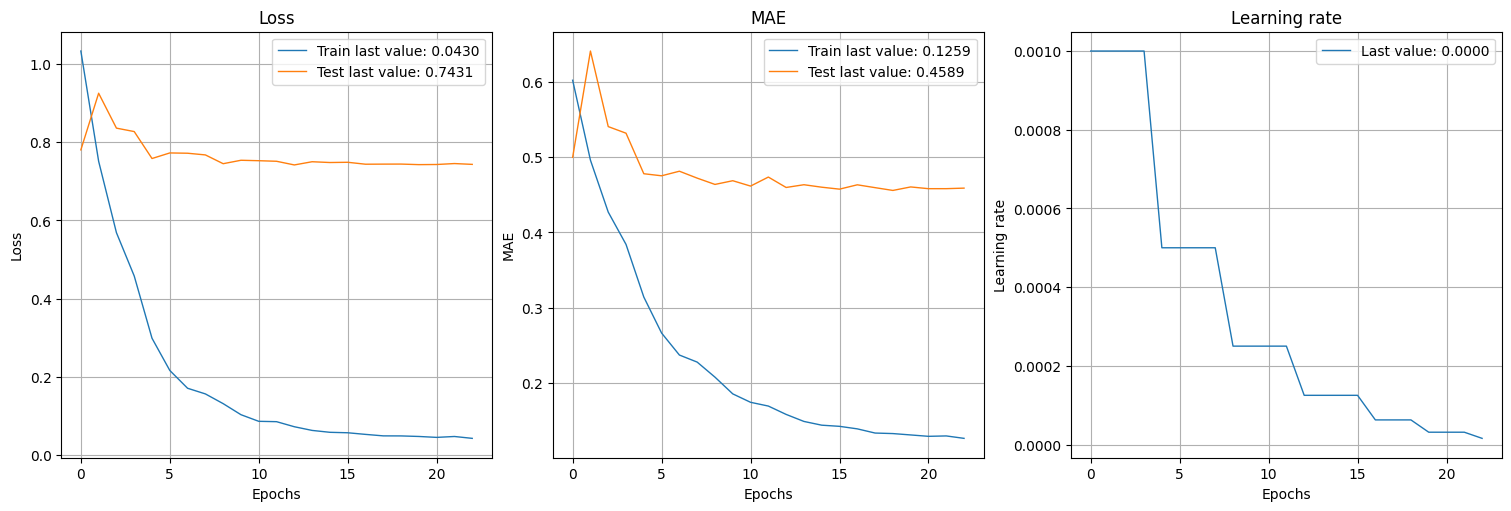

In [18]:
# from plot_keras_history import plot_history

# plot_history(history)

In [19]:
# from sklearn.metrics import mean_absolute_error

# preds_tr = model.predict(X_tr, verbose=0)
# preds_te = model.predict(X_te, verbose=0)

# # baseline = per-column median constant predictor on TRAIN
# median_train = np.median(y_tr, axis=0)
# baseline_mae = float(mean_absolute_error(
#     y_tr, np.full_like(y_tr, median_train)
# ))
# train_mae = float(mean_absolute_error(y_tr, preds_tr))
# test_mae = float(mean_absolute_error(y_te, preds_te))

# print(f"baseline mae (train, median):  {baseline_mae:.4f}")
# print(f"train mae:                      {train_mae:.4f}")
# print(f"test mae:                       {test_mae:.4f}")
# print(f"model beats by (test-baseline):  {baseline_mae - test_mae:.4f}")


baseline mae (train, median):  0.7541
train mae:                      0.1079
test mae:                       0.4623
model beats by (test-baseline):  0.2918


In [20]:
# joblib.dump(model, '../linreg.joblib')

In [21]:
# scaled MAE: 0.4676   raw MAE: ~3,558 engagement
# 6,000 <-- 10,000 --> 14,000
# baseline mae (median, scaled): 0.7376
# model mae (scaled):           0.4676
# Model better than baseline by         0.270

### CLAS NN (permutation)

In [22]:
# from sklearn.preprocessing import StandardScaler
# from keras.utils import to_categorical

# N_BINS = 2

# def _iqr_binned(series, n=N_BINS):
#     q1 = series.quantile(0.25)
#     q3 = series.quantile(0.75)
#     iqr = q3 - q1
#     edges = np.linspace(q1 - 1.5 * iqr, q3 + 1.5 * iqr, n + 1)
#     return np.clip(np.digitize(series.to_numpy(), edges) - 1, 0, n - 1).astype(int)

# views_bin = _iqr_binned(df['views'])
# engagement_bin = _iqr_binned(df['engagement'])

# y_categories = pd.Categorical(
#     [f"views_{v}_engagement_{e}" for v, e in zip(views_bin, engagement_bin)]
# )
# y = to_categorical(y_categories.codes, num_classes=N_BINS * N_BINS)
# y_label = pd.Series(y_categories.categories[y_categories.codes], index=df.index)

# DROP_COLS = ['views', 'engagement']
# X_all = df.drop(columns=DROP_COLS)

# NUMERIC_COLS = [c for c in [
#     'duration_seconds', 'description_cluster', 'title_cluster',
#     'n_mentions', 'n_hashtags', 'n_emojis',
#     'hashtag_count', 'mention_count', 'emoji_count',
# ] if c in X_all.columns]
# binary_cols = [c for c in X_all.columns if c not in set(NUMERIC_COLS)]

# scaler_X = StandardScaler()
# scaler_X.fit(X_all.iloc[idx_tr][NUMERIC_COLS])

# _build_X = lambda i: pd.concat(
#     [
#         pd.DataFrame(
#             scaler_X.transform(X_all.iloc[i][NUMERIC_COLS]),
#             columns=NUMERIC_COLS,
#             index=X_all.iloc[i].index,
#         ),
#         X_all.iloc[i][binary_cols],
#     ],
#     axis=1,
# )

# X_tr = _build_X(idx_tr)
# X_vl = _build_X(idx_vl_inner)
# X_te = _build_X(idx_te)

# y_tr = y[idx_tr]
# y_vl = y[idx_vl_inner]
# y_te = y[idx_te]
# codes_tr = y_tr.argmax(axis=1)
# codes_vl = y_vl.argmax(axis=1)
# codes_te = y_te.argmax(axis=1)

# print("X_tr", X_tr.shape, "y_tr", y_tr.shape)
# print("X_vl", X_vl.shape, "y_vl", y_vl.shape)
# print("X_te", X_te.shape, "y_te", y_te.shape)


X_tr (6886, 6333) y_tr (6886, 4)
X_vl (1722, 6333) y_vl (1722, 4)
X_te (2152, 6333) y_te (2152, 4)


In [23]:
# print("X (full):", X_all.shape, "y (full):", y.shape)

# counts = pd.Series(codes_tr).value_counts().sort_index()
# for code, n in counts.items():
#     print(f"  {y_categories.categories[code]}: {n}")
# print(f"\nTotal train rows: {len(codes_tr)}")


X (full): (10760, 6333) y (full): (10760, 4)
  views_0_engagement_0: 3979
  views_0_engagement_1: 300
  views_1_engagement_0: 383
  views_1_engagement_1: 2224

Total train rows: 6886


In [24]:
# from keras import Input
# from keras import Sequential, layers

# model = Sequential()
# model.add(Input(shape=(X_tr.shape[1],)))


# model.add(layers.Dense(1611, activation='relu'))
# model.add(layers.Dropout(rate=0.3))
# model.add(layers.Dense(3200, activation='relu'))
# model.add(layers.Dropout(rate=0.3)) 
# model.add(layers.Dense(1611, activation='relu'))
# model.add(layers.Dropout(rate=0.3)) 

# model.add(layers.Dense(y.shape[1], activation='softmax'))


# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1611)           │    10,204,074 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1611)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3200)           │     5,158,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1611)           │     5,156,811 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1611)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         6,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,525,733 (78.30 MB)

 Trainable params: 20,525,733 (78.30 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# es = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
# rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

# history = model.fit(
#     X_tr, y_tr,
#     batch_size=32,
#     epochs=1000,
#     validation_data=(X_vl, y_vl),
#     callbacks=[es, rop],
# )


Epoch 1/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7562 - loss: 0.3139 - val_accuracy: 0.7828 - val_loss: 0.2713 - learning_rate: 0.0010
Epoch 2/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8144 - loss: 0.2333 - val_accuracy: 0.7805 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 3/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8539 - loss: 0.1784 - val_accuracy: 0.7491 - val_loss: 0.3174 - learning_rate: 0.0010
Epoch 4/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8954 - loss: 0.1301 - val_accuracy: 0.7515 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 5/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9508 - loss: 0.0618 - val_accuracy: 0.7631 - val_loss: 0.4959 - learning_rate: 5.0000e-04
Epoch 6/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9731 - loss: 0.0356 - val_accuracy: 0.7549 - val_loss: 0.5949 - learning_rate: 5.0000e-04
Epoch 7/1000
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accur

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Accuracy'}, xlabel='Epochs', ylabel='Accuracy'>,
        <Axes: title={'center': 'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <Axes: title={'center': 'Learning rate'}, xlabel='Epochs', ylabel='Learning rate'>],
       dtype=object))

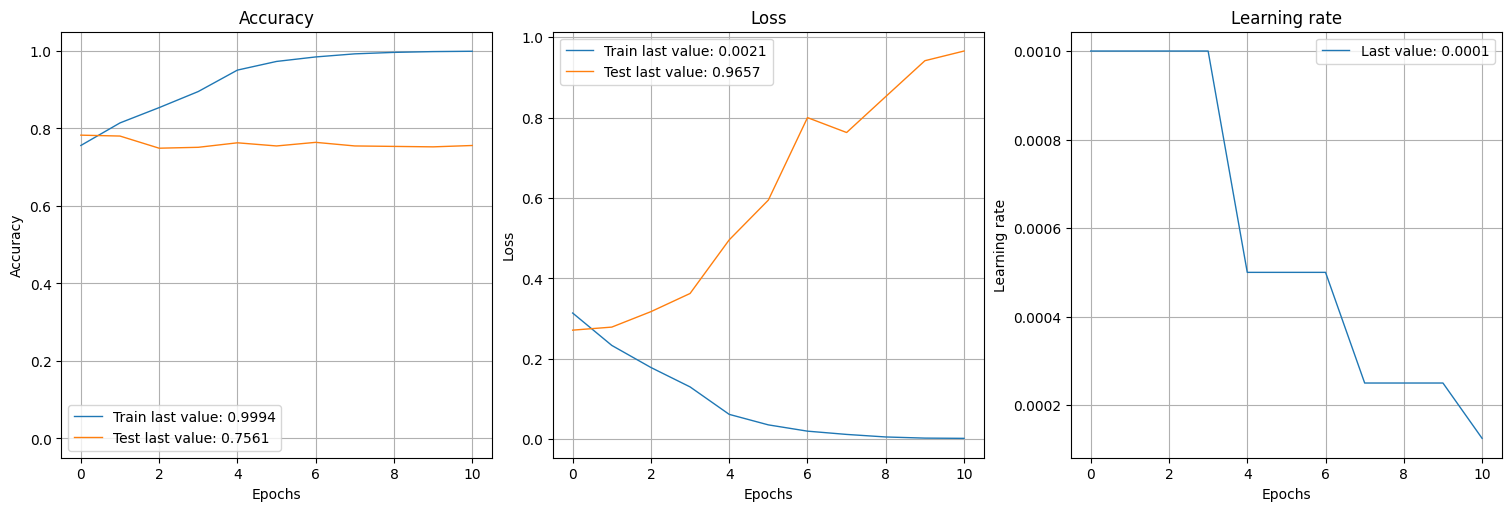

In [26]:
# from plot_keras_history import plot_history

# plot_history(history)

In [27]:
# from sklearn.metrics import accuracy_score

# majority_class = int(pd.Series(codes_tr).mode().iloc[0])
# majority_label = y_categories.categories[majority_class]
# majority_share = float(pd.Series(codes_tr).value_counts(normalize=True).iloc[0])
# baseline_pred = np.full(len(codes_te), majority_class, dtype=int)
# baseline_acc = accuracy_score(codes_te, baseline_pred)
# print(f"majority class:         {majority_label}  share={majority_share:.4f}")
# print(f"baseline accuracy (test): {baseline_acc:.4f}")

# best_epoch = int(np.argmax(history.history['val_accuracy']))
# train_accuracy = history.history['accuracy'][best_epoch]
# print(f"Training accuracy:      {train_accuracy:.4f}")

# pred_codes_te = model.predict(X_te, verbose=0).argmax(axis=1)
# test_acc = float(accuracy_score(codes_te, pred_codes_te))
# print(f"Test accuracy:          {test_acc:.4f}")

# print(f"model beats by (test): {test_acc - baseline_acc:.4f}")


majority class:         views_0_engagement_0  share=0.5778
baseline accuracy (test): 0.5813
Training accuracy:      0.7562
Test accuracy:          0.7872
model beats by (test): 0.2059


In [28]:
# joblib.dump(model, '../classify.joblib')

### CLAS NN (2head)

In [29]:
# mask = (df['views'] > 0) & (df['engagement'] > 0)
# print(f"drop {(~mask).sum()} rows; remaining: {len(df) - (~mask).sum()}")
# df = df[mask]

In [30]:
# df_copy = df.copy()

In [31]:
# print(len(df))
# Q1 = df_copy['views'].quantile(0.1)
# Q3 = df_copy['views'].quantile(0.9)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# df_copy = df_copy[(df_copy['views'] >= lower_bound) & (df_copy['views'] <= upper_bound)]


# Q1 = df_copy['engagement'].quantile(0.1)
# Q3 = df_copy['engagement'].quantile(0.9)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# df_copy = df_copy[(df_copy['engagement'] >= lower_bound) & (df_copy['engagement'] <= upper_bound)]
# print(len(df_copy))

In [32]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from keras.utils import to_categorical

# N_BINS = 2

# def _iqr_binned(series, n=N_BINS):
#     q1 = series.quantile(0.25)
#     q3 = series.quantile(0.75)
#     iqr = q3 - q1
#     edges = np.linspace(q1 - 1.5 * iqr, q3 + 1.5 * iqr, n + 1)
#     return np.clip(np.digitize(series.to_numpy(), edges) - 1, 0, n - 1).astype(int)

# views_bin = _iqr_binned(df_copy['views'])
# engagement_bin = _iqr_binned(df_copy['engagement'])

# y_views = to_categorical(views_bin, num_classes=N_BINS)
# y_engagement = to_categorical(engagement_bin, num_classes=N_BINS)

# DROP_COLS = ['views', 'engagement']
# X = df_copy.drop(columns=DROP_COLS)

# X_train, X_test, y_views_train, y_views_test, y_engagement_train, y_engagement_test = train_test_split(
#     X, y_views, y_engagement, test_size=0.2, random_state=42
# )


# # Standardise unscaled numeric X columns so they do not dominate the dense layer.
# NUMERIC_COLS = [c for c in [
#     'duration_seconds', 'description_cluster', 'title_cluster',
#     'n_mentions', 'n_hashtags', 'n_emojis',
#     'hashtag_count', 'mention_count', 'emoji_count',
# ] if c in X_train.columns]
# binary_cols = [c for c in X_train.columns if c not in set(NUMERIC_COLS)]

# scaler_X = StandardScaler()
# X_train_num = scaler_X.fit_transform(X_train[NUMERIC_COLS])
# X_test_num  = scaler_X.transform(X_test[NUMERIC_COLS])

# X_train = pd.concat(
#     [pd.DataFrame(X_train_num, columns=NUMERIC_COLS, index=X_train.index),
#      X_train[binary_cols]],
#     axis=1,
# )
# X_test = pd.concat(
#     [pd.DataFrame(X_test_num, columns=NUMERIC_COLS, index=X_test.index),
#      X_test[binary_cols]],
#     axis=1,
# )


In [33]:
# print("X:            ", X.shape)
# print("y_views:      ", y_views.shape)
# print("y_engagement: ", y_engagement.shape)

# print("\nviews_bin distribution (train):")
# codes = y_views_train.argmax(axis=1)
# for code, n in pd.Series(codes).value_counts().sort_index().items():
#     print(f"  views_bin_{code}: {n}")
# print(f"  total train rows: {len(codes)}")

# print("\nengagement_bin distribution (train):")
# codes = y_engagement_train.argmax(axis=1)
# for code, n in pd.Series(codes).value_counts().sort_index().items():
#     print(f"  engagement_bin_{code}: {n}")
# print(f"  total train rows: {len(codes)}")

In [34]:
# from keras import Input
# from keras.models import Model
# from keras import layers

# # model.add(layers.Dense(1611, activation='relu'))
# # model.add(layers.Dropout(rate=0.3))
# # model.add(layers.Dense(3200, activation='relu'))
# # model.add(layers.Dropout(rate=0.3)) 
# # model.add(layers.Dense(1611, activation='relu'))
# # model.add(layers.Dropout(rate=0.3)) 

# shared_input = Input(shape=(X.shape[1],))

# x = layers.Dense(1611, activation='relu')(shared_input)
# x = layers.Dropout(rate=0.2)(x)
# x = layers.Dense(3200, activation='relu')(x)
# x = layers.Dropout(rate=0.2)(x)
# x = layers.Dense(1611, activation='relu')(x)
# x = layers.Dropout(rate=0.2)(x)

# views_head = layers.Dense(N_BINS, activation='softmax', name='views')(x)
# engagement_head = layers.Dense(N_BINS, activation='softmax', name='engagement')(x)

# model = Model(inputs=shared_input, outputs=[views_head, engagement_head])

# model.compile(
#     loss={'views': 'categorical_crossentropy', 'engagement': 'categorical_crossentropy'},
#     optimizer='adam',
#     metrics={'views': 'accuracy', 'engagement': 'accuracy'},
# )
# model.summary()

In [35]:
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')
# rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

# history = model.fit(
#     X_train,
#     {'views': y_views_train, 'engagement': y_engagement_train},
#     batch_size=32,
#     epochs=1000,
#     validation_split=0.2,
#     callbacks=[es, rop],
# )

In [36]:
# from plot_keras_history import plot_history

# plot_history(history)

In [37]:
# results = model.evaluate(
#     X_test,
#     {'views': y_views_test, 'engagement': y_engagement_test},
#     verbose=0,
# )
# print(f"Test total loss:           {results[0]:.4f}")
# print(f"Test views loss:           {results[1]:.4f}")
# print(f"Test engagement loss:      {results[2]:.4f}")
# print(f"Test views accuracy:       {results[3]:.4f}")
# print(f"Test engagement accuracy:  {results[4]:.4f}")

In [38]:
# from sklearn.metrics import accuracy_score

# pred_views, pred_engagement = model.predict(X_test, verbose=0)
# pred_views = pred_views.argmax(axis=1)
# pred_engagement = pred_engagement.argmax(axis=1)

# truth_views = y_views_test.argmax(axis=1)
# truth_engagement = y_engagement_test.argmax(axis=1)

# codes_train_v = y_views_train.argmax(axis=1)
# codes_train_e = y_engagement_train.argmax(axis=1)

# majority_v = int(pd.Series(codes_train_v).mode().iloc[0])
# majority_e = int(pd.Series(codes_train_e).mode().iloc[0])
# share_v = float(pd.Series(codes_train_v).value_counts(normalize=True).iloc[0])
# share_e = float(pd.Series(codes_train_e).value_counts(normalize=True).iloc[0])

# baseline_v = accuracy_score(truth_views, np.full(len(truth_views), majority_v, dtype=int))
# baseline_e = accuracy_score(truth_engagement, np.full(len(truth_engagement), majority_e, dtype=int))
# model_v = float(results[3])
# model_e = float(results[4])

# majority_v_pred = np.full(len(truth_views), majority_v, dtype=int)
# majority_e_pred = np.full(len(truth_engagement), majority_e, dtype=int)
# baseline_joint = float(np.mean(
#     (majority_v_pred == truth_views) & (majority_e_pred == truth_engagement)
# ))
# model_joint = float(np.mean(
#     (pred_views == truth_views) & (pred_engagement == truth_engagement)
# ))

# print(f"majority views_bin:        {majority_v}   share={share_v:.4f}")
# print(f"majority engagement_bin:   {majority_e}   share={share_e:.4f}")
# print()
# print(f"baseline views_acc:        {baseline_v:.4f}")
# print(f"model    views_acc:        {model_v:.4f}")
# print(f"model views improvement:        {model_v - baseline_v:.4}")
# print(f"baseline engagement_acc:   {baseline_e:.4f}")
# print(f"model    engagement_acc:   {model_e:.4f}")
# print(f"model engagement improvement:        {model_e - baseline_e:.4}")

# print()
# print(f"baseline joint_acc:        {baseline_joint:.4f}")
# print(f"model    joint_acc:        {model_joint:.4f}")

# print(f"model joint improvement:        {model_joint - baseline_joint:.4}")

### SVM linreg

In [39]:
# X / y setup using shared split (mirrors LINREG NN)
from sklearn.preprocessing import StandardScaler, RobustScaler

DROP_COLS = ['views', 'engagement']

X_all = df.drop(columns=DROP_COLS)
y_all = df[['engagement', 'views']]

NUMERIC_COLS = [c for c in [
    'duration_seconds', 'description_cluster', 'title_cluster',
    'n_mentions', 'n_hashtags', 'n_emojis',
    'hashtag_count', 'mention_count', 'emoji_count',
] if c in X_all.columns]
binary_cols = [c for c in X_all.columns if c not in set(NUMERIC_COLS)]

scaler_X = StandardScaler()
scaler_X.fit(X_all.iloc[idx_tr][NUMERIC_COLS])

_build_X = lambda i: pd.concat(
    [
        pd.DataFrame(
            scaler_X.transform(X_all.iloc[i][NUMERIC_COLS]),
            columns=NUMERIC_COLS,
            index=X_all.iloc[i].index,
        ),
        X_all.iloc[i][binary_cols],
    ],
    axis=1,
)

X_tr = _build_X(idx_tr)
X_vl = _build_X(idx_vl_inner)
X_te = _build_X(idx_te)

scaler_y = RobustScaler()
scaler_y.fit(y_all.iloc[idx_tr])
y_tr = scaler_y.transform(y_all.iloc[idx_tr])
y_vl = scaler_y.transform(y_all.iloc[idx_vl_inner])
y_te = scaler_y.transform(y_all.iloc[idx_te])

print("X_tr", X_tr.shape, "y_tr", y_tr.shape)
print("X_vl", X_vl.shape, "y_vl", y_vl.shape)
print("X_te", X_te.shape, "y_te", y_te.shape)

# poly-kernel SVM, single train/val split (no inner CV).
# Anchored at regression best:
#   {'estimator__C': 1.0, 'estimator__coef0': 0.0,
#    'estimator__degree': 2, 'estimator__gamma': 'scale'}
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error

param_grid = {
    'estimator__C': [1.0],       # regressor best
    'estimator__degree': [2],    # regressor best
    'estimator__gamma': ['scale'],# regressor best
    'estimator__coef0': [0.0],   # regressor best
}

# Grid search over param_grid; train on X_tr / score on X_vl (single split).
best_val_mae = float('inf')
best_params = None
for params in ParameterGrid(param_grid):
    m = MultiOutputRegressor(SVR(kernel='poly'))
    m.set_params(**params)
    m.fit(X_tr, y_tr)
    v_mae = float(mean_absolute_error(y_vl, m.predict(X_vl)))
    if v_mae < best_val_mae:
        best_val_mae = v_mae
        best_params = params

# Refit best params on train + inner-val for the final estimator.
X_train_full = pd.concat([X_tr, X_vl], axis=0)
y_train_full = np.vstack([y_tr, y_vl])
final_model = MultiOutputRegressor(SVR(kernel='poly'))
final_model.set_params(**best_params)
final_model.fit(X_train_full, y_train_full)
test_mae = float(mean_absolute_error(y_te, final_model.predict(X_te)))

print(f"best params:     {best_params}")
print(f"val mae:         {best_val_mae:.4f}")
print(f"test mae:        {test_mae:.4f}")

# baseline: per-column median constant predictor on TRAIN
baseline_mae = float(np.mean(np.abs(y_tr - np.median(y_tr, axis=0))))
print(f"baseline mae:    {baseline_mae:.4f}")

print(f"model beats by (test): {baseline_mae - test_mae:.4f}")


X_tr (6886, 6333) y_tr (6886, 2)
X_vl (1722, 6333) y_vl (1722, 2)
X_te (2152, 6333) y_te (2152, 2)
best params:     {'estimator__C': 1.0, 'estimator__coef0': 0.0, 'estimator__degree': 2, 'estimator__gamma': 'scale'}
val mae:         0.4793
test mae:        0.4796
baseline mae:    0.7541
model beats by (test): 0.2745


In [40]:
# best params
# (10760, 6333)
# (10760, 2)
# Fitting 3 folds for each of 1 candidates, totalling 3 fits
# best params:   {'estimator__C': 1.0, 'estimator__coef0': 0.0, 'estimator__degree': 2, 'estimator__gamma': 'scale'}
# best val mae:  0.4920
# baseline mae:  0.7487
# model beats by: 0.2568

### SVM classify

In [41]:
# X / y setup using shared split (mirrors CLAS NN (permutation))
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical

N_BINS = 2

def _iqr_binned(series, n=N_BINS):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    edges = np.linspace(q1 - 1.5 * iqr, q3 + 1.5 * iqr, n + 1)
    return np.clip(np.digitize(series.to_numpy(), edges) - 1, 0, n - 1).astype(int)

views_bin = _iqr_binned(df['views'])
engagement_bin = _iqr_binned(df['engagement'])

y_categories = pd.Categorical(
    [f"views_{v}_engagement_{e}" for v, e in zip(views_bin, engagement_bin)]
)
y = to_categorical(y_categories.codes, num_classes=N_BINS * N_BINS)
y_label = pd.Series(y_categories.categories[y_categories.codes], index=df.index)

DROP_COLS = ['views', 'engagement']
X_all = df.drop(columns=DROP_COLS)

NUMERIC_COLS = [c for c in [
    'duration_seconds', 'description_cluster', 'title_cluster',
    'n_mentions', 'n_hashtags', 'n_emojis',
    'hashtag_count', 'mention_count', 'emoji_count',
] if c in X_all.columns]
binary_cols = [c for c in X_all.columns if c not in set(NUMERIC_COLS)]

scaler_X = StandardScaler()
scaler_X.fit(X_all.iloc[idx_tr][NUMERIC_COLS])

_build_X = lambda i: pd.concat(
    [
        pd.DataFrame(
            scaler_X.transform(X_all.iloc[i][NUMERIC_COLS]),
            columns=NUMERIC_COLS,
            index=X_all.iloc[i].index,
        ),
        X_all.iloc[i][binary_cols],
    ],
    axis=1,
)

X_tr = _build_X(idx_tr)
X_vl = _build_X(idx_vl_inner)
X_te = _build_X(idx_te)

y_tr = y[idx_tr]
y_vl = y[idx_vl_inner]
y_te = y[idx_te]
codes_tr = y_tr.argmax(axis=1)
codes_vl = y_vl.argmax(axis=1)
codes_te = y_te.argmax(axis=1)

print("X_tr", X_tr.shape, "y_tr", y_tr.shape)
print("X_vl", X_vl.shape, "y_vl", y_vl.shape)
print("X_te", X_te.shape, "y_te", y_te.shape)

# poly-kernel SVC. Grid search anchored at regression best:
#   regression best: {'estimator__C': 1.0, 'estimator__coef0': 0.0,
#                     'estimator__degree': 2, 'estimator__gamma': 'scale'}
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score

param_grid = {
    'C': [1.0],         # regression best
    'degree': [2],      # regression best
    'gamma': ['scale'], # regression best
    'coef0': [0.0],     # regression best
}

# Grid search over param_grid; train on X_tr / score on X_vl (single split).
best_val_acc = -float('inf')
best_params = None
for params in ParameterGrid(param_grid):
    m = SVC(kernel='poly')
    m.set_params(**params)
    m.fit(X_tr, codes_tr)
    v_acc = float(accuracy_score(codes_vl, m.predict(X_vl)))
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_params = params

# Refit best params on train + inner-val + score on test
X_train_full = pd.concat([X_tr, X_vl], axis=0)
codes_train_full = np.concatenate([codes_tr, codes_vl])
final_model = SVC(kernel='poly')
final_model.set_params(**best_params)
final_model.fit(X_train_full, codes_train_full)
test_acc = float(accuracy_score(codes_te, final_model.predict(X_te)))

print(f"best params:    {best_params}")
print(f"val acc:        {best_val_acc:.4f}")
print(f"test acc:       {test_acc:.4f}")

# Training accuracy of refit best (analog of CLAS NN's history.history['accuracy'][best_epoch])
train_accuracy = float(accuracy_score(codes_train_full, final_model.predict(X_train_full)))

# Mimic CLAS NN (permutation) log block
majority_class = int(pd.Series(codes_tr).mode().iloc[0])
majority_label = y_categories.categories[majority_class]
majority_share = float(pd.Series(codes_tr).value_counts(normalize=True).iloc[0])
baseline_pred = np.full(len(codes_te), majority_class, dtype=int)
baseline_acc = accuracy_score(codes_te, baseline_pred)

print(f"majority class:    {majority_label}  share={majority_share:.4f}")
print(f"baseline accuracy: {baseline_acc:.4f}")

print(f"Training accuracy: {train_accuracy:.4f}")

print(f"model beats by (test): {test_acc - baseline_acc:.4f}")


X_tr (6886, 6333) y_tr (6886, 4)
X_vl (1722, 6333) y_vl (1722, 4)
X_te (2152, 6333) y_te (2152, 4)
best params:    {'C': 1.0, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale'}
val acc:        0.8014
test acc:       0.7955
majority class:    views_0_engagement_0  share=0.5778
baseline accuracy: 0.5813
Training accuracy: 0.8446
model beats by (test): 0.2142


In [42]:
# Fitting 3 folds for each of 1 candidates, totalling 3 fits
# best params:    {'C': 1.0, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale'}
# majority class:    views_0_engagement_0
# baseline accuracy: 0.5783
# Training accuracy: 0.7974
# model beats by: 0.2191